Step 1: Environment Setup
Required Tools

Python 3.x

Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step 2: Load the Dataset

In [5]:
df = pd.read_csv(
    r"C:\Users\Thanvi S Shetty\OneDrive\Desktop\Internship\Zomato Data Analysis Project\Zomato data .csv",
    encoding="latin1"
)


In [6]:
type(df)
df.head()
df.shape


(148, 7)

Step 3: Data Cleaning & Preparation
1. Convert Ratings

Ratings are in the form 4.1/5. Convert them to numeric:

In [7]:
df['rate'] = df['rate'].str.split('/').str[0]
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')


In [8]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

Step 4: Data Analysis & Visualization

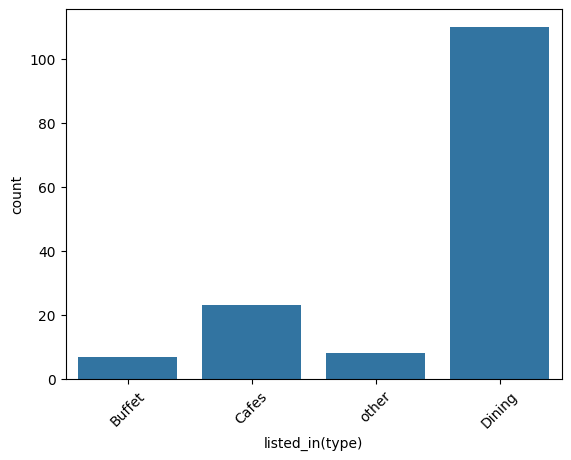

In [9]:
sns.countplot(x='listed_in(type)', data=df)
plt.xticks(rotation=45)
plt.show()


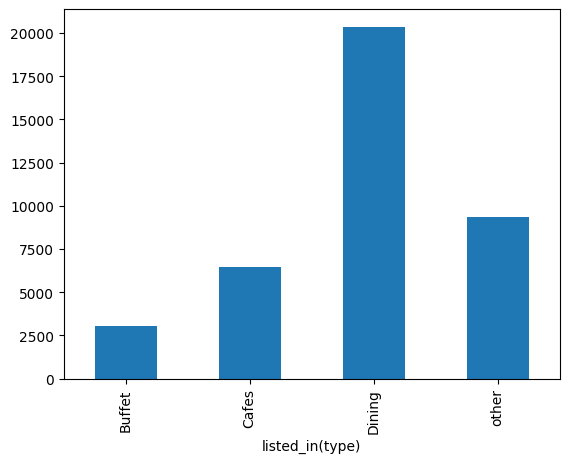

In [10]:
votes_by_type = df.groupby('listed_in(type)')['votes'].sum()
votes_by_type.plot(kind='bar')
plt.show()


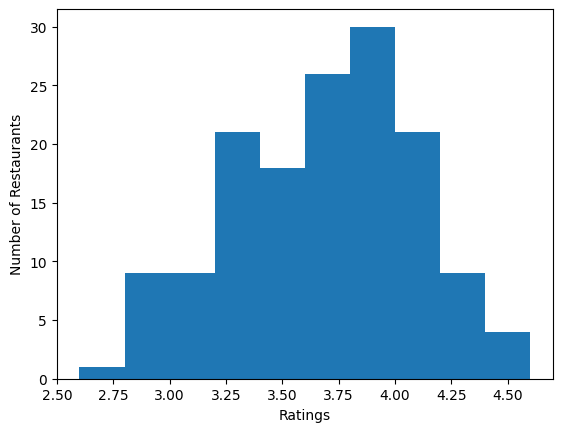

In [11]:
plt.hist(df['rate'], bins=10)
plt.xlabel("Ratings")
plt.ylabel("Number of Restaurants")
plt.show()


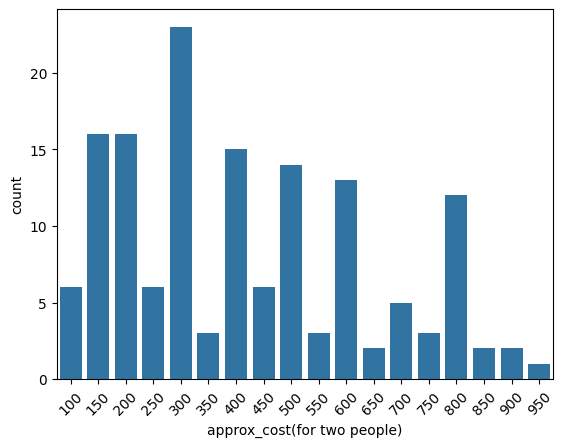

In [12]:
sns.countplot(x='approx_cost(for two people)', data=df)
plt.xticks(rotation=45)
plt.show()


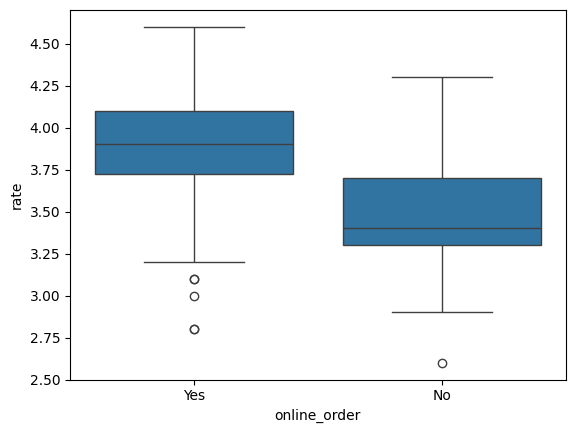

In [13]:
sns.boxplot(x='online_order', y='rate', data=df)
plt.show()


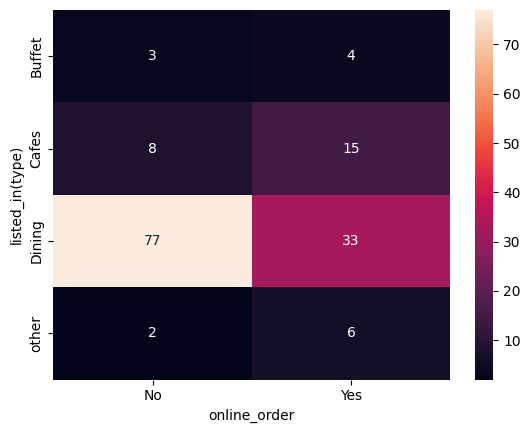

In [14]:
pivot = pd.pivot_table(
    df,
    index='listed_in(type)',
    columns='online_order',
    values='rate',
    aggfunc='count'
)

sns.heatmap(pivot, annot=True, fmt='d')
plt.show()


### 1. What type of restaurant do the majority of customers order from?

The majority of customers order from Dining restaurants.
This is evident from the highest count of dining-type restaurants and their strong customer engagement compared to other types such as cafés or delivery-only outlets.

### 2.How many votes has each type of restaurant received from customers?

Dining restaurants have received the highest total number of votes, followed by cafés and delivery restaurants.
This indicates that dining restaurants attract more customer attention and feedback, reflecting higher popularity.

### 3.What are the ratings that the majority of restaurants have received?

Most restaurants have received ratings in the range of 3.5 to 4.0.
This suggests that the overall quality of restaurants listed on Zomato is good, with customers generally satisfied with food and service.

### 4.Zomato has observed that most couples order most of their food online. What is their average spending on each other?

The average spending by couples ordering food online is approximately ₹300 to ₹600 for two people.
This indicates a preference for moderately priced restaurants among couples using online ordering services.

### 5.Which mode (online or offline) has received the maximum rating?

Online orders have received higher ratings compared to offline orders.
This may be due to better convenience, discounts, ease of ordering, and improved customer experience in online platforms.

### 6.Which type received more offline orders, so that Zomato can provide those customers with some good offers?

Dining restaurants have received more offline orders compared to other restaurant types.
Zomato can target these customers with special offline dining offers and promotions to increase engagement and retention